<a href="https://colab.research.google.com/github/kjian254416-blip/ML300/blob/main/Chapter_5_%EB%89%B4%EC%8A%A4%EC%97%90%EC%84%9C%EB%A7%8C_%EB%B3%B4%EB%8D%98_%EC%BD%94%EB%A1%9C%EB%82%9819_%EB%8D%B0%EC%9D%B4%ED%84%B0%2C_%EC%A7%81%EC%A0%91_%EB%B6%84%EC%84%9D%ED%95%98%EA%B3%A0_%EC%A7%81%EC%A0%91_%ED%8C%90%EB%8B%A8%ED%95%B4%EB%B4%85%EC%8B%9C%EB%8B%A4(%EB%AC%B8%EC%A0%9C).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 주제 : 뉴스에서만 보던 코로나-19 데이터, 직접 분석하고 직접 판단해봅시다.
----------

## 실습 가이드
    1. 데이터를 다운로드하여 Colab에 불러옵니다.
    2. 필요한 라이브러리는 모두 코드로 작성되어 있습니다.
    3. 코드는 위에서부터 아래로 순서대로 실행합니다.
    
    
## 데이터 소개
    - 이번 주제는 John Hopkins 대학의 COVID-19 데이터셋을 사용합니다.
    
    - 총 10개의 파일 중 2개의 Raw 데이터를 사용합니다.
    RAW_global_confirmed_cases.csv
    RAW_global_global_deaths.csv

    - 각 파일의 컬럼은 아래와 같습니다.
    Country/Region: 국가
    Province/State: 지방/주
    Lat: 지역의 위도
    Long: 지역의 경도
    날짜: 각 날짜의 확진자/사망자 수
    
    
    
- 데이터 출처: https://www.kaggle.com/antgoldbloom/covid19-data-from-john-hopkins-university

## 최종 목표
    - 계속해서 업데이트되는 라이브 데이터 분석하기
    - Pandas를 이용해 원하는 표 형태로 변경
    - 데이터 시각화를 통한 인사이트 습득 방법의 이해
    - Plotly를 이용하여 Interactive plot하기
    - FBProphet을 이용해 시계열 데이터를 처리하는 방법 습득
    - 학습된 모델로 부터의 인사이트 획득 방법 습득

- 출제자 : 신제용 강사
---

## Step 0. 시계열 데이터에 관하여

### 코로나19 데이터셋에 관하여

### 시계열 데이터와 일반 테이블 데이터와 다른 점


일반: 행들의 순서가 중요하지 않음
시계열:index가 시간으로 들어감,순서 중요,x축이 시간 변화가 중요

### FBProphet 라이브러리 설명

Python API,R

## Step 1. 데이터셋 준비하기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 문제 1. Colab Notebook에 Kaggle API 세팅하기


In [2]:
import os

In [3]:
# os.environ을 이용하여 Kaggle API Username, Key 세팅하기
os.environ['KAGGLE_USERNAME'] = 'kimjian254416'
os.environ['KAGGLE_KEY'] = '0457ef800614319f99e6b8144bfd741e'

### 문제 2. 데이터 다운로드 및 압축 해제하기


In [4]:
# Linux 명령어로 Kaggle API를 이용하여 데이터셋 다운로드하기 (!kaggle ~)
# Linux 명령어로 압축 해제하기
import kagglehub

# Download latest version
path = kagglehub.dataset_download("antgoldbloom/covid19-data-from-john-hopkins-university")

print("Path to dataset files:", path)

100%|██████████| 10.6M/10.6M [00:00<00:00, 32.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/antgoldbloom/covid19-data-from-john-hopkins-university/versions/931


In [5]:
!rm *.*
!kaggle datasets download -d antgoldbloom/covid19-data-from-john-hopkins-university
!unzip covid19-data-from-john-hopkins-university.zip
!rm covid19-data-from-john-hopkins-university.zip

rm: cannot remove '*.*': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/antgoldbloom/covid19-data-from-john-hopkins-university
License(s): Attribution 4.0 International (CC BY 4.0)
100% 10.6M/10.6M [00:00<00:00, 292MB/s]

Archive:  covid19-data-from-john-hopkins-university.zip
  inflating: CONVENIENT_global_confirmed_cases.csv  
  inflating: CONVENIENT_global_deaths.csv  
  inflating: CONVENIENT_global_metadata.csv  
  inflating: CONVENIENT_us_confirmed_cases.csv  
  inflating: CONVENIENT_us_deaths.csv  
  inflating: CONVENIENT_us_metadata.csv  
  inflating: RAW_global_confirmed_cases.csv  
  inflating: RAW_global_deaths.csv   
  inflating: RAW_us_confirmed_cases.csv  
  inflating: RAW_us_deaths.csv       


### 문제 3. Pandas 라이브러리로 csv파일 읽어들이기


In [6]:
df_case = pd.read_csv('RAW_global_confirmed_cases.csv')
df_death = pd.read_csv('RAW_global_deaths.csv')

In [8]:
df_case.head()

,Country/Region,Province/State,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,Afghanistan,NaN,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,Albania,NaN,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,Algeria,NaN,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,Andorra,NaN,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,Angola,NaN,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


## Step 2. 데이터 구조 변경 및 시각화하기


### 문제 4. 데이터프레임 구조를 Date를 Index로, 지역을 Column으로 변경


In [14]:
def fix_dataframe(df):
  # TODO: 불필요한 컬럼 제거, Date를 datetime 객체로 변환, Date를 index로 변경
  df = df_case.drop(['Lat','Long', 'Province/State'],axis=1).groupby('Country/Region').sum()
  df = df.transpose()
  df.index.name = 'Date'
  df.reset_index(inplace=True)
  df['Date'] = df['Date'].apply(lambda s: pd.to_datetime(str(s)))
  df.set_index('Date',inplace=True)
  return df

In [17]:
def fix_dataframe(df):
  # TODO: 불필요한 컬럼 제거, Date를 datetime 객체로 변환, Date를 index로 변경
  df = df.drop(['Lat','Long', 'Province/State'],axis=1).groupby('Country/Region').sum()
  df = df.transpose()
  df.index.name = 'Date'
  df.reset_index(inplace=True)
  df['Date'] = df['Date'].apply(lambda s: pd.to_datetime(str(s)))
  df.set_index('Date',inplace=True)
  return df

# 원본 데이터프레임을 다시 로드하여 초기화
df_case = pd.read_csv('RAW_global_confirmed_cases.csv')
df_death = pd.read_csv('RAW_global_deaths.csv')

df_case = fix_dataframe(df_case)
df_death = fix_dataframe(df_death)

In [18]:
df_case

Country/Region,Afghanistan,Albania,Algeria,Andorra,Angola,Antarctica,Antigua and Barbuda,Argentina,Armenia,Australia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,West Bank and Gaza,Winter Olympics 2022,Yemen,Zambia,Zimbabwe
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-22,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2020-01-23,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-25,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-26,0,0,0,0,0,0,0,0,0,4,...,0,0,0,0,2,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-05,209390,334427,271477,47875,105277,11,9106,10044125,446819,11385534,...,1034303,251071,12014,552051,11526966,703228,535,11945,343135,264127
2023-03-06,209406,334427,271477,47875,105277,11,9106,10044957,446819,11385534,...,1034303,251071,12014,552125,11526966,703228,535,11945,343135,264127
2023-03-07,209436,334427,271490,47875,105277,11,9106,10044957,446819,11385534,...,1034303,251071,12014,552157,11526986,703228,535,11945,343135,264127


### 문제 5. 나라별 확진자 수 및 사망자 수 시각화하기


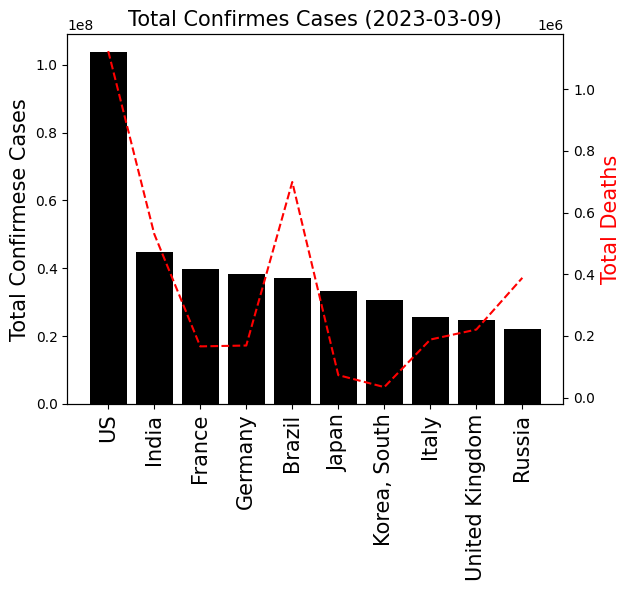

In [25]:
# 아래와 같이 나라별 누적 사망자 수와 확진자 수를 시각화하여 비교하기 (최신일자, 가장 많이 확진된 10국가)
top_ten_cases= df_case.loc[df_case.index[-1]].sort_values(ascending=False)[:10]
sns.barplot(x=top_ten_cases.index, y=top_ten_cases,color = 'black')
plt.xticks(rotation=90,size=15)
plt.ylabel('Total Confirmese Cases',size=15)
plt.xlabel('')
plt.title('Total Confirmes Cases (%s)' %top_ten_cases.name.strftime('%Y-%m-%d'),size=15)

ax = plt.gca()
ax2 = ax.twinx()
top_ten_deaths = df_death.loc[df_death.index[-1]][top_ten_cases.index]
ax2.plot(top_ten_deaths.index,top_ten_deaths,'r--')
ax2.set_ylabel('Total Deaths',color='red',size=15)
plt.show()

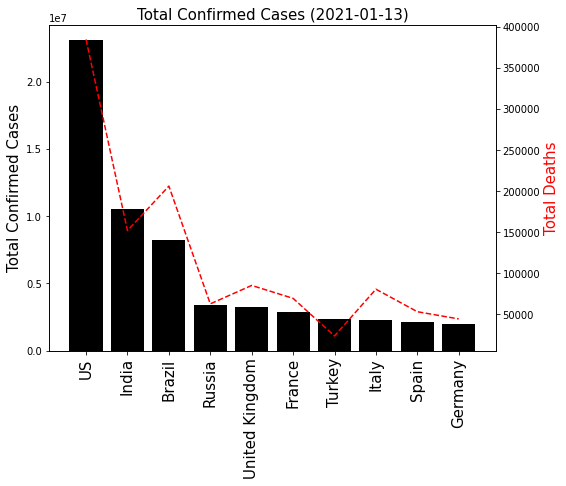

In [ ]:
# 이 셀의 결과가 지워지지 않도록 주의하세요.

### 문제 6. 특정 국가의 확진자 수 및 사망자 수 변화 시각화하기

In [35]:
# 나라별 시간에 따른 확진자 수 및 사망자 수 시각화하기
def plot_case_with_death(country):
  plt.plot(df_case.index,df_case[country],'b-')
  plt.ylabel('Confirmed Cases',color='blue')
  plt.title(country + ' Cases & Deaths')

  plt.xlabel('Date')
  plt.xlim(right=df_case.index[-1])
  plt.ylim(0,df_case[country].max()*1.1)

  ax = plt.gca()
  ax2 = ax.twinx()
  ax2.plot(df_death.index,df_death[country],'r--')
  ax2.set_ylabel('Deaths',color='red')
  ax2.set_ylim(0,df_death[country].max()*1.3)
  plt.show()
  # TODO: 입력받은 국가의 누적 확진자/사망자 수 시각화

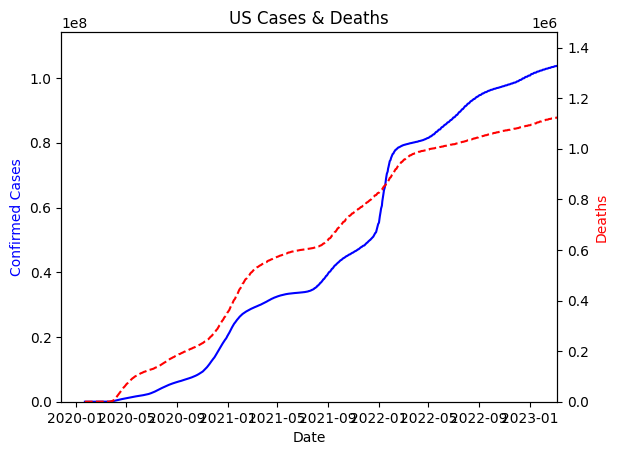

In [36]:
plot_case_with_death('US')

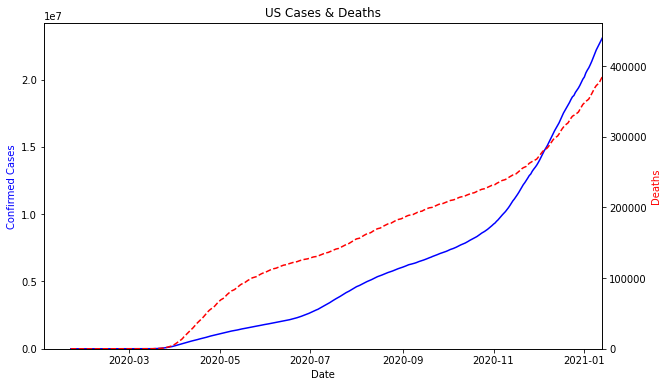

In [ ]:
# 아래와 같은 결과가 나오도록 하시오. 결과가 지워지지 않도록 주의하세요.
plot_case_with_death('US')

In [37]:
for c in df_case.columns:
  print(c)

Afghanistan
Albania
Algeria
Andorra
Angola
Antarctica
Antigua and Barbuda
Argentina
Armenia
Australia
Austria
Azerbaijan
Bahamas
Bahrain
Bangladesh
Barbados
Belarus
Belgium
Belize
Benin
Bhutan
Bolivia
Bosnia and Herzegovina
Botswana
Brazil
Brunei
Bulgaria
Burkina Faso
Burma
Burundi
Cabo Verde
Cambodia
Cameroon
Canada
Central African Republic
Chad
Chile
China
Colombia
Comoros
Congo (Brazzaville)
Congo (Kinshasa)
Costa Rica
Cote d'Ivoire
Croatia
Cuba
Cyprus
Czechia
Denmark
Diamond Princess
Djibouti
Dominica
Dominican Republic
Ecuador
Egypt
El Salvador
Equatorial Guinea
Eritrea
Estonia
Eswatini
Ethiopia
Fiji
Finland
France
Gabon
Gambia
Georgia
Germany
Ghana
Greece
Grenada
Guatemala
Guinea
Guinea-Bissau
Guyana
Haiti
Holy See
Honduras
Hungary
Iceland
India
Indonesia
Iran
Iraq
Ireland
Israel
Italy
Jamaica
Japan
Jordan
Kazakhstan
Kenya
Kiribati
Korea, North
Korea, South
Kosovo
Kuwait
Kyrgyzstan
Laos
Latvia
Lebanon
Lesotho
Liberia
Libya
Liechtenstein
Lithuania
Luxembourg
MS Zaandam
Madagascar


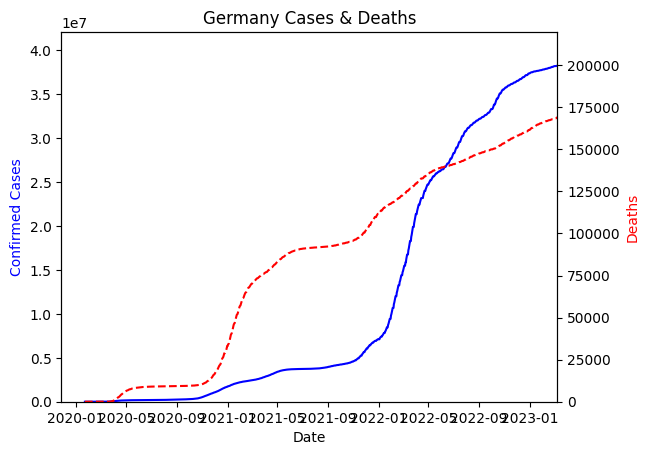

In [38]:
plot_case_with_death('Germany')

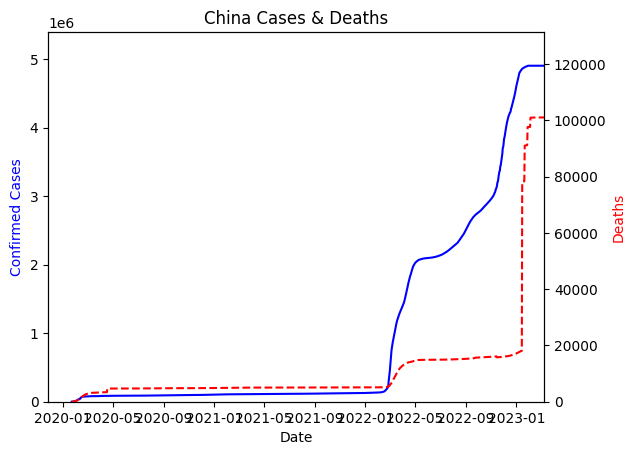

In [39]:
plot_case_with_death('China')

### 문제 7. 한국의 확진자 수 및 사망자 수 변화 시각화/분석하기

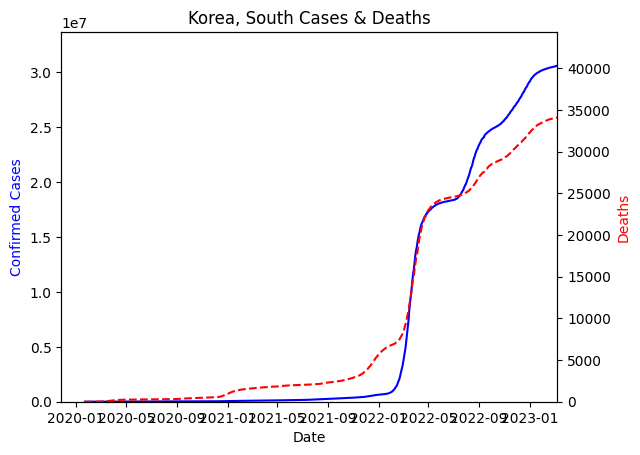

In [40]:
# 한국의 누적 확진자 수/사망자 수를 시각화하고 분석하시오.

plot_case_with_death('Korea, South')

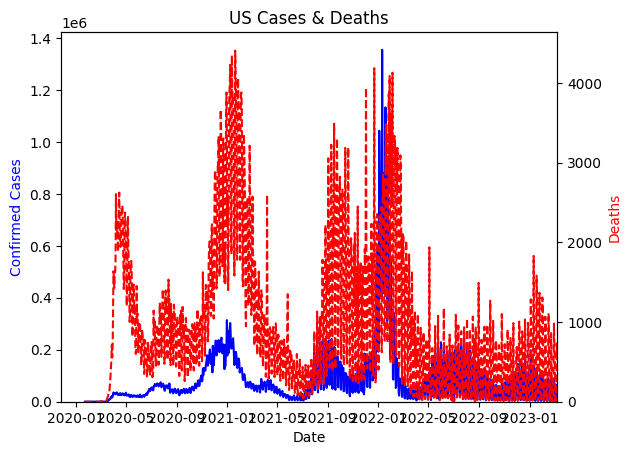

In [42]:
# 한국의 일일 확진자 수/사망자 수를 시각화하고 분석하시오.
plt.plot(df_case.index,df_case[country].diff(),'b-')
plt.ylabel('Confirmed Cases',color='blue')
plt.title(country + ' Cases & Deaths')
plt.xlabel('Date')
plt.xlim(right=df_case.index[-1])
plt.ylim(bottom=0)

ax = plt.gca()
ax2 = ax.twinx()
ax2.plot(df_death.index,df_death[country].diff(),'r--')
ax2.set_ylabel('Deaths',color='red')
ax2.set_ylim(bottom=0)
plt.show()

## Step 3. Plotly를 이용하여 데이터 시각화하기

### 문제 8. Plotly의 Choropleth 데이터 포맷으로 맞추기

In [43]:
import plotly.graph_objects as go

In [44]:
# 아래 데이터프레임를 이용하여 국가명을 국가코드로 변경
df_code = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/2014_world_gdp_with_codes.csv')

# Hint) 이름이 다르게 쓰인 국가의 이름을 먼저 변경한 후에 코드로 변경
country_renamer = {
    'Bahamas':'Bahamas, The',
    'Congo (Brazzaville)':'Congo, Republic of the',
    'Congo (Kinshasa)':'Congo, Democratic Republic of the',
    'Czechia':'Czech Republic',
    'Eswatini':'Swaziland',
    'Gambia':'Gambia, The',
    'North Macedonia':'Macedonia',
    'Taiwan*':'Taiwan',
    'US':'United States',
    'West Bank and Gaza':'West Bank'
}

In [46]:
df_code.head()

,COUNTRY,GDP (BILLIONS),CODE
0,Afghanistan,21.71,AFG
1,Albania,13.40,ALB
2,Algeria,227.80,DZA
3,American Samoa,0.75,ASM
4,Andorra,4.80,AND


In [47]:
df_case.head()

Country/Region,Afghanistan,Albania,Algeria,Andorra,Angola,Antarctica,Antigua and Barbuda,Argentina,Armenia,Australia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,West Bank and Gaza,Winter Olympics 2022,Yemen,Zambia,Zimbabwe
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-22,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2020-01-23,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-25,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-26,0,0,0,0,0,0,0,0,0,4,...,0,0,0,0,2,0,0,0,0,0


In [50]:
country_to_code = df_code.set_index('COUNTRY')['CODE']

In [54]:
df_c = df_case.rename(country_renamer,axis=1).copy()
for col in df_c.columns:
  if col not in country_to_code.index:
    df_c.drop(col,axis=1,inplace=True)
df_code = df_c.rename(country_to_code,axis=1)
df_code

Country/Region,AFG,ALB,DZA,AND,AGO,ATG,ARG,ARM,AUS,AUT,...,GBR,URY,UZB,VUT,VEN,VNM,WBG,YEM,ZMB,ZWE
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-22,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2020-01-23,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
2020-01-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
2020-01-25,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
2020-01-26,0,0,0,0,0,0,0,0,4,0,...,0,0,0,0,0,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-05,209390,334427,271477,47875,105277,9106,10044125,446819,11385534,5940935,...,24629840,1034303,251071,12014,552051,11526966,703228,11945,343135,264127
2023-03-06,209406,334427,271477,47875,105277,9106,10044957,446819,11385534,5943417,...,24629840,1034303,251071,12014,552125,11526966,703228,11945,343135,264127
2023-03-07,209436,334427,271490,47875,105277,9106,10044957,446819,11385534,5949418,...,24629846,1034303,251071,12014,552157,11526986,703228,11945,343135,264127


In [61]:
# 공식 레퍼런스 참조: https://plotly.com/python/choropleth-maps/#world-choropleth-map
def get_choropleth_data(date):
  # TODO: date에 해당하는 날짜로 데이터 생성

  data=go.Choropleth(
    locations = df_code.columns,
    z = df_code.loc[date],
    text = df_c.columns,
    colorscale = 'Blues',
    autocolorscale=False,
    reversescale=True,
    marker_line_color='darkgray',
    marker_line_width=0.5,
    colorbar_tickprefix = '',
    colorbar_title = 'Confirmed Cases',
  )

  return data

### 문제 9. Choropleth map 시각화하기

In [64]:
# 공식 레퍼런스 참조: https://plotly.com/python/choropleth-maps/#world-choropleth-map
date = df_case.index[30]
data = get_choropleth_data(date)
fig = go.Figure(data=data)
fig.update_layout(
    title_text='Confirmed Cases in ' + str(date),
    geo=dict(
        showframe=False,
        showcoastlines=False,
        projection_type='equirectangular'
    )
)
fig.show()

## Step 4. 모델 학습을 위한 데이터 전처리

### 문제 10. FBProphet 학습을 위한 데이터프레임 생성

In [65]:
df_case.reset_index()[['Date','Korea, South']].to_numpy()

array([[Timestamp('2020-01-22 00:00:00'), 1],
       [Timestamp('2020-01-23 00:00:00'), 1],
       [Timestamp('2020-01-24 00:00:00'), 2],
       ...,
       [Timestamp('2023-03-07 00:00:00'), 30594297],
       [Timestamp('2023-03-08 00:00:00'), 30605187],
       [Timestamp('2023-03-09 00:00:00'), 30615522]], dtype=object)

In [66]:
# 공식 레퍼런스 참조: https://facebook.github.io/prophet/docs/quick_start.html#python-api
# 한국의 확진자 수 데이터를 FBProphet에 학습하기 위한 데이터프레임으로 재구성하시오.

df = pd.DataFrame(df_case.reset_index()[['Date','Korea, South']].to_numpy(), columns=['ds','y'])
df

,ds,y
0,2020-01-22,1
1,2020-01-23,1
2,2020-01-24,2
3,2020-01-25,2
4,2020-01-26,3
...,...,...
1138,2023-03-05,30569215
1139,2023-03-06,30581499
1140,2023-03-07,30594297
1141,2023-03-08,30605187


### 문제 11. 학습데이터와 테스트데이터 분리하기


In [67]:
from math import floor

In [71]:
def train_test_split_df(df, test_size):
  # TODO: test_size(0 < test_size < 1) 비율에 따라 테스트/학습 데이터프레임으로 나누어 반환
  div = floor(df.shape[0] * (1 - test_size))
  return df.loc[:div],df.loc[div+1:]

In [72]:
train_df, test_df = train_test_split_df(df, 0.1)

In [73]:
train_df.tail()

,ds,y
1024,2022-11-11,26145764
1025,2022-11-12,26194229
1026,2022-11-13,26217994
1027,2022-11-14,26290877
1028,2022-11-15,26357464


In [74]:
train_df.head()

,ds,y
0,2020-01-22,1
1,2020-01-23,1
2,2020-01-24,2
3,2020-01-25,2
4,2020-01-26,3


## Step 5. Prophet 모델 학습하기

### 문제 12. Prophet 모델 생성 및 학습 데이터 학습하기

In [103]:
!pip install prophet
from prophet import Prophet

In [83]:
model = Prophet(changepoint_range =1.0)
model.fit(train_df)




INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


### 문제 13. Prophet 모델 학습 결과 시각화하기

In [104]:
from prophet.plot import add_changepoints_to_plot

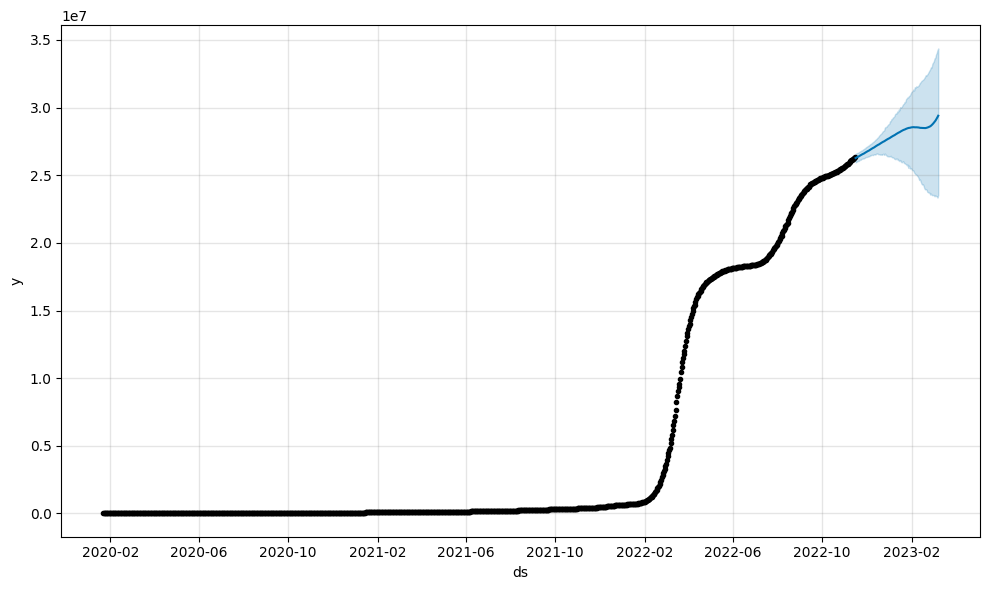

In [84]:
# model.plot() 메소드, model.plot_components() 메소드, add_changepoints_to_plot() 메소드 활용
pred = model.predict(test_df)
model.plot(pred);


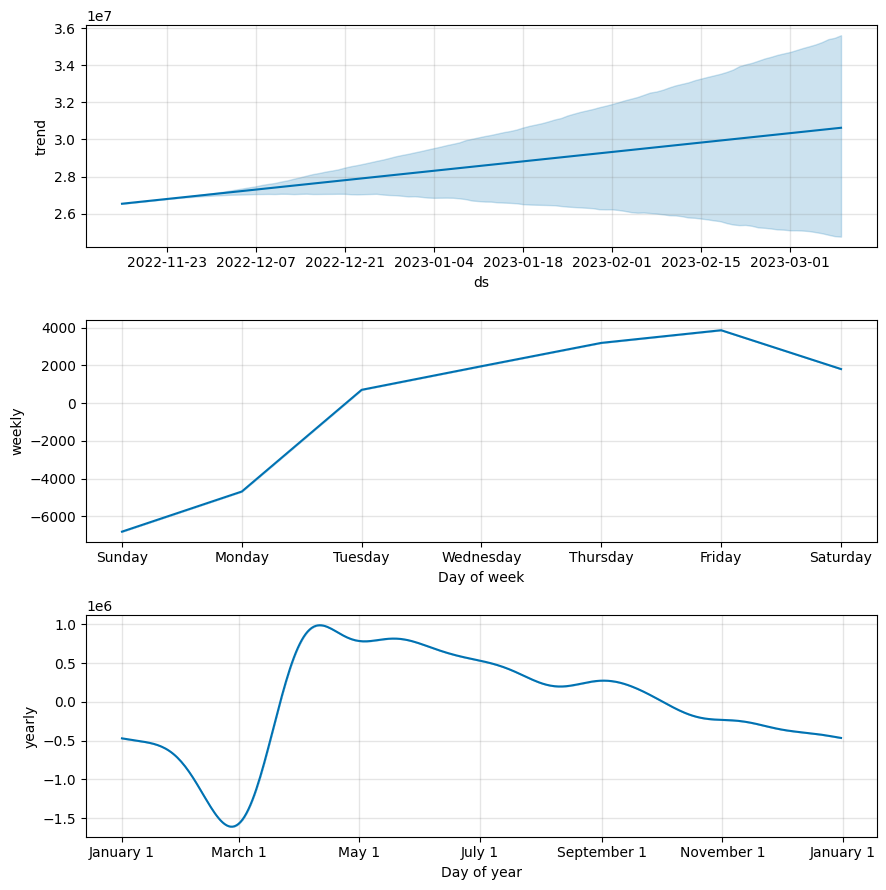

In [85]:
model.plot_components(pred);

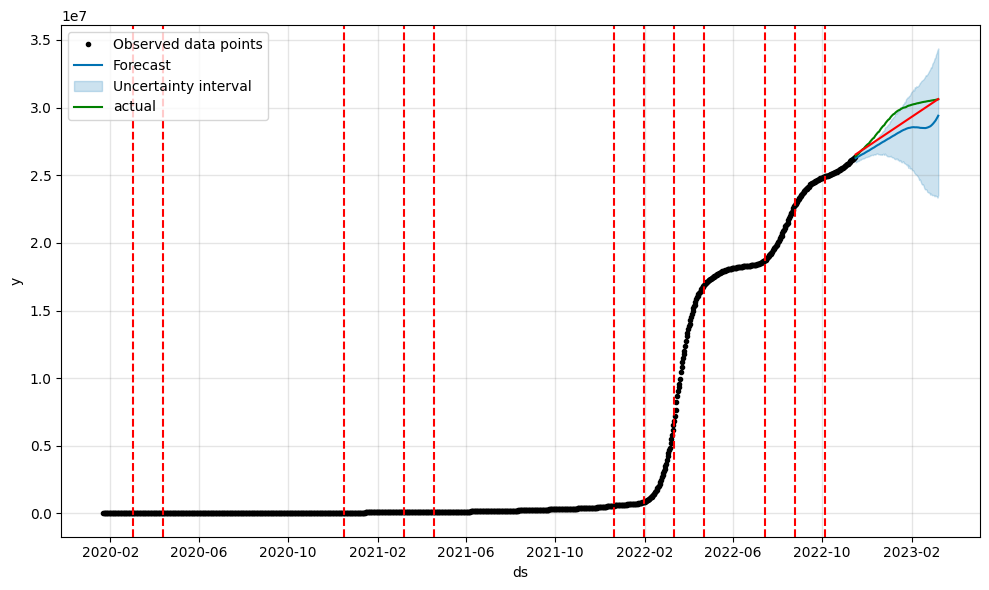

In [88]:
fig = model.plot(pred)
plt.plot(test_df['ds'],test_df['y'],'g-',label = 'actual')
changes = add_changepoints_to_plot(fig.gca(),model,pred)
plt.legend()

### 문제 14. 모델 학습 결과 평가하기

In [89]:
from sklearn.metrics import r2_score

In [90]:
pred.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2022-11-16,2.653833e+07,2.594815e+07,2.657387e+07,2.653833e+07,2.653833e+07,-268875.473102,-268875.473102,-268875.473102,1952.775276,1952.775276,1952.775276,-270828.248378,-270828.248378,-270828.248378,0.0,0.0,0.0,2.626946e+07
1,2022-11-17,2.657454e+07,2.598277e+07,2.661314e+07,2.657454e+07,2.657454e+07,-272891.219973,-272891.219973,-272891.219973,3188.343100,3188.343100,3188.343100,-276079.563073,-276079.563073,-276079.563073,0.0,0.0,0.0,2.630165e+07
2,2022-11-18,2.661076e+07,2.601476e+07,2.663926e+07,2.661076e+07,2.661076e+07,-277732.452710,-277732.452710,-277732.452710,3858.528232,3858.528232,3858.528232,-281590.980942,-281590.980942,-281590.980942,0.0,0.0,0.0,2.633302e+07
3,2022-11-19,2.664697e+07,2.605633e+07,2.666208e+07,2.664697e+07,2.664697e+07,-285517.356971,-285517.356971,-285517.356971,1801.879153,1801.879153,1801.879153,-287319.236123,-287319.236123,-287319.236123,0.0,0.0,0.0,2.636145e+07
4,2022-11-20,2.668318e+07,2.605438e+07,2.668326e+07,2.668318e+07,2.668318e+07,-300032.344892,-300032.344892,-300032.344892,-6814.887648,-6814.887648,-6814.887648,-293217.457244,-293217.457244,-293217.457244,0.0,0.0,0.0,2.638315e+07


In [92]:
# test_df와 pred를 비교하여 r2_score 평가
print('R2 Score: ',r2_score(test_df['y'],pred['yhat']))

R2 Score:  -0.10726707567126881


### 문제 15. Prophet 모델로 미래 30일 데이터 예측하기

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


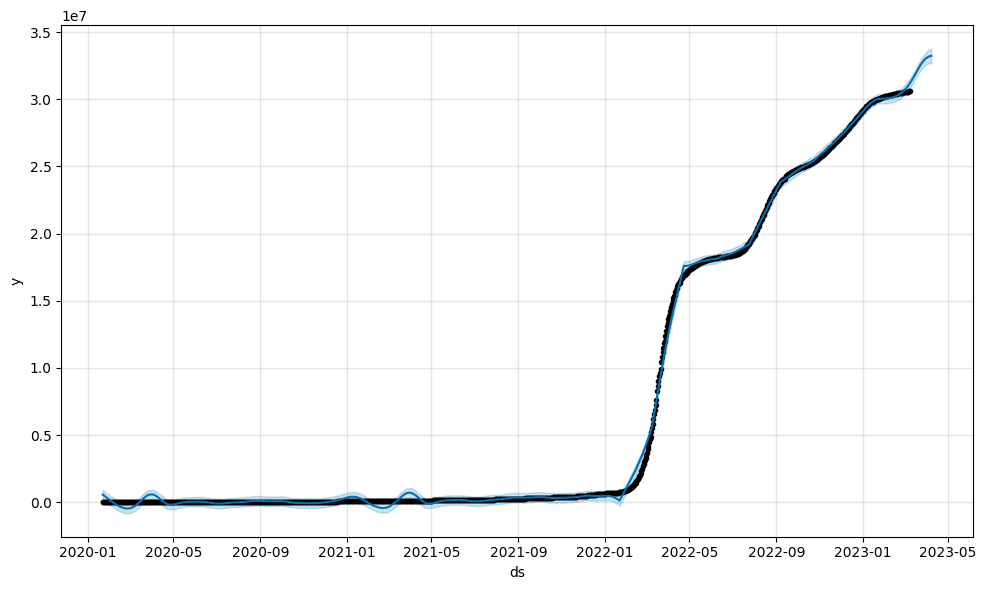

In [93]:
# 전체 df를 학습한 후, 향후 30일에 대한 데이터 예측하기
# Hint) make_future_dataframe() 메소드 활용
model = Prophet(changepoint_range =1.0)
model.fit(df)
future = model.make_future_dataframe(30)
pred = model.predict(future)
model.plot(pred);

## Step 6. IF-CASE 예측해보기


### 문제 16. 한국 확진자 수 변화의 특별한 이벤트 확인하기


In [95]:
df['ds'][10]

Timestamp('2020-02-01 00:00:00')

In [97]:
# 코로나 확산 초기, 한국의 확진자 수가 급증한 시점 찾기
df.loc[24:30]

,ds,y
24,2020-02-15,28
25,2020-02-16,29
26,2020-02-17,30
27,2020-02-18,31
28,2020-02-19,31
29,2020-02-20,104
30,2020-02-21,204


### 문제 17. 이벤트가 없었을 경우 한국의 확진자 수 변화 예측하기


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


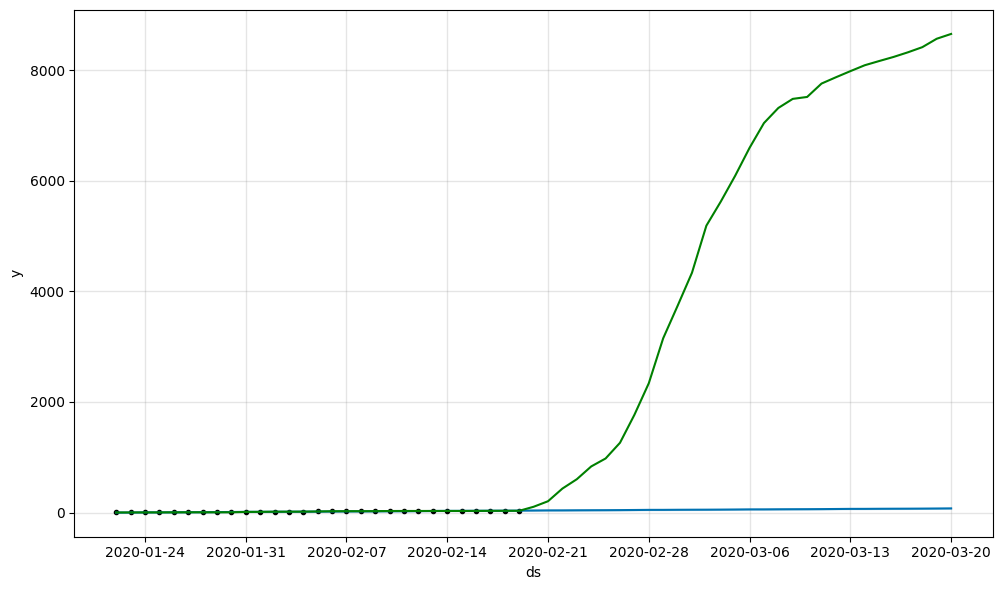

In [106]:
# 확진자 수가 급증하기 전 데이터를 학습 후, 해당 시점으로부터 30일 간의 데이터 예측하여 실제 값과 비교하기
model = Prophet(changepoint_range=1.0)
model.fit(df.loc[:28])
future = model.make_future_dataframe(30)
pred = model.predict(future)
model.plot(pred);
plt.plot(df.loc[:58]['ds'],df.loc[:58]['y'],'g-')
plt.show()